# 💰 FinSight-AI  
## Smart Expense Analytics & Financial Insight System  

### 📊 ML Major Project Documentation (EDA + Data Visualization)
Department of Information Science and Engineering  

This project analyzes financial transactions to extract meaningful insights using Python.

## Submitted By  
- KrishnaKumar CM
- Pooja R
- Sneha
- Syed Zubair 

## Technologies Used  
- Python  
- Machine Learning (EDA-based Analysis)  
- Pandas  
- NumPy  
- Matplotlib  
- Seaborn  
- Jupyter Notebook  

# Aim of the Project  

The aim of this project is to develop a Smart Expense Analytics System using Data Analysis and Machine Learning techniques.

The system helps users to:
- Analyze financial transactions  
- Track ₹ spending patterns  
- Identify category-wise expenses  
- Visualize monthly trends  
- Improve budgeting decisions  

# Objectives  

The main objectives of this project are:

- To analyze financial expense datasets using data analysis techniques  
- To visualize spending patterns using graphs and charts  
- To identify category-wise expenditure behavior  
- To study monthly expense trends and variations  
- To detect unusual spending patterns (outliers)  
- To generate meaningful insights for better financial decisions  

# Import Libraries  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset  

In [2]:
df = pd.read_csv("expenses.csv")
df.head()

,Date,Category,Amount,Payment_Mode,Month,Tax
0,01-01-2024,Transport,3279,Cash,May,328
1,02-01-2024,Entertainment,2080,Card,December,208
2,02-01-2024,Transport,3217,Online,December,322
3,02-01-2024,Utilities,1054,Online,May,105
4,05-01-2024,Food,13249,Cash,December,1325


## Data Display with ₹ Format

We format Amount and Tax columns for better readability in financial representation.

In [7]:
display_df = df.copy()

display_df["Amount"] = display_df["Amount"].apply(lambda x: f"₹{float(x):,.2f}")
display_df["Tax"] = display_df["Tax"].apply(lambda x: f"₹{float(x):,.2f}")

display_df[["Date","Category","Amount","Payment_Mode","Tax"]].head()

,Date,Category,Amount,Payment_Mode,Tax
0,01-01-2024,Transport,"₹3,279.00",Cash,₹328.00
1,02-01-2024,Entertainment,"₹2,080.00",Card,₹208.00
2,02-01-2024,Transport,"₹3,217.00",Online,₹322.00
3,02-01-2024,Utilities,"₹1,054.00",Online,₹105.00
4,05-01-2024,Food,"₹13,249.00",Cash,"₹1,325.00"


# Dataset Information  

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          1000 non-null   object
 1   Category      1000 non-null   object
 2   Amount        1000 non-null   int64 
 3   Payment_Mode  1000 non-null   object
 4   Month         1000 non-null   object
 5   Tax           1000 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 47.0+ KB


In [9]:
df.describe()

,Amount,Tax
count,1000.000000,1000.000000
mean,7676.692000,767.727000
std,4347.352771,434.738528
min,101.000000,10.000000
25%,3781.250000,378.000000
50%,7938.000000,793.500000
75%,11442.250000,1144.250000
max,14999.000000,1500.000000


#  Data Preparation (₹ Conversion)  

In [10]:
df["Amount_numeric"] = df["Amount"]
df["Tax_numeric"] = df["Tax"]

# Financial Summary  

In [11]:
print("Total Expense: ₹", df["Amount_numeric"].sum())
print("Total Tax: ₹", df["Tax_numeric"].sum())
print("Average Expense: ₹", df["Amount_numeric"].mean())

Total Expense: ₹ 7676692
Total Tax: ₹ 767727
Average Expense: ₹ 7676.692


# 1. Univariate Analysis  
Univariate analysis involves analyzing a single variable to understand its distribution and pattern.

##  Expense Distribution (₹)

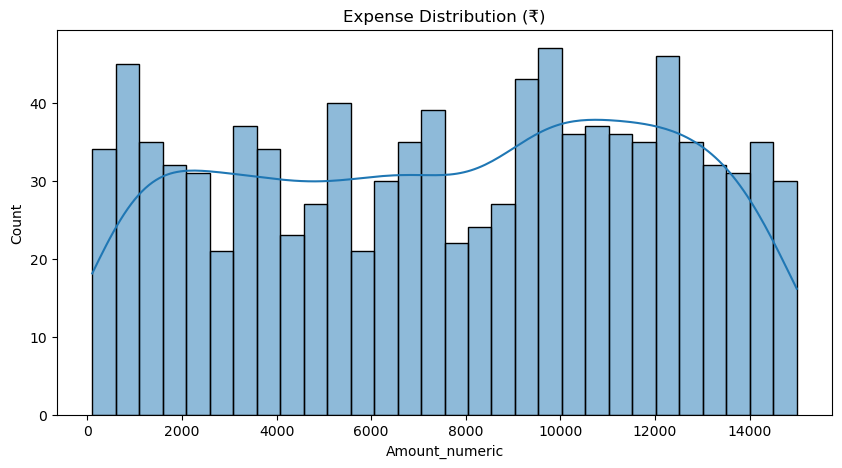

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df["Amount_numeric"], bins=30, kde=True)
plt.title("Expense Distribution (₹)")
plt.show()

Insight : Expenses are mostly distributed in mid-range ₹ values, showing balanced spending behavior.

##  Outlier Detection  

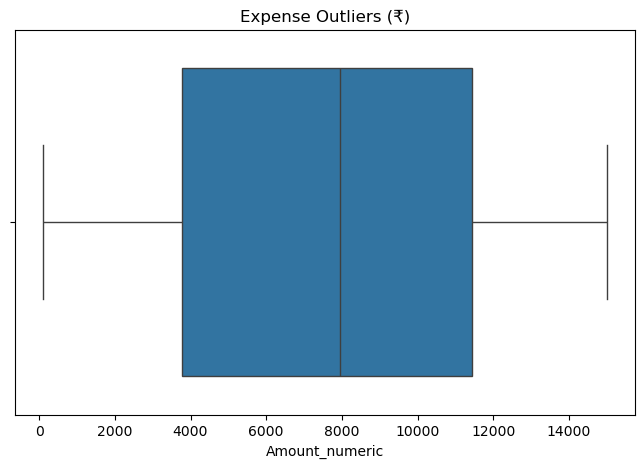

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Amount_numeric"])
plt.title("Expense Outliers (₹)")
plt.show()

Insight : A few high-value ₹ transactions indicate occasional large purchases.

## Category Distribution  

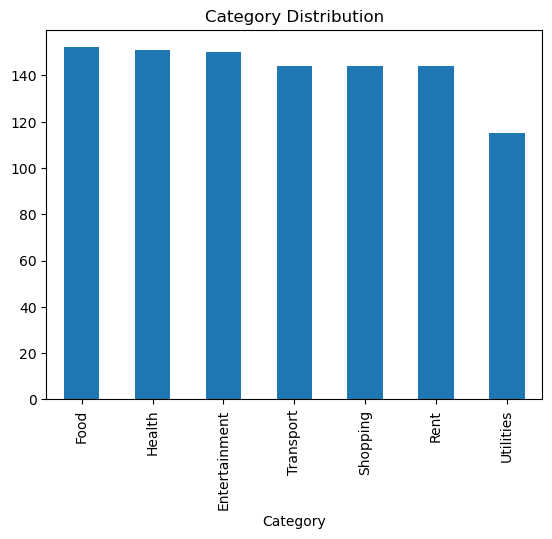

In [14]:
df["Category"].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.show()

Insight : Food and Travel categories dominate overall expenses.

# 2. Bivariate Analysis  
Bivariate analysis studies the relationship between two variables.

## Category vs Expense (₹)  

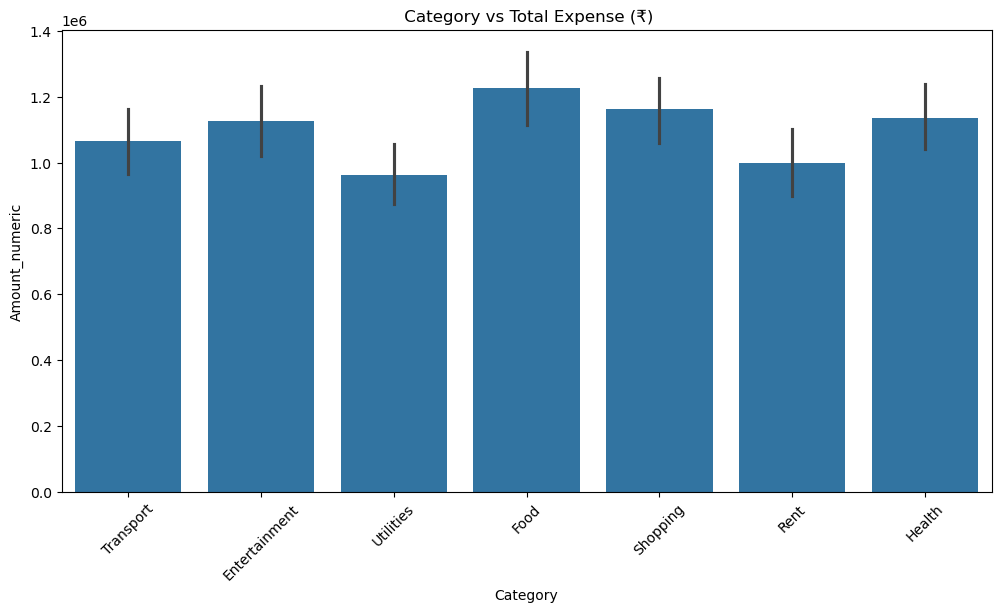

In [15]:
plt.figure(figsize=(12,6))
sns.barplot(x="Category", y="Amount_numeric", data=df, estimator=sum)
plt.xticks(rotation=45)
plt.title(" Category vs Total Expense (₹)")
plt.show()

Insight : Certain categories like Food and Travel contribute highest ₹ expenses.

##  Monthly Expense Trend (₹)  

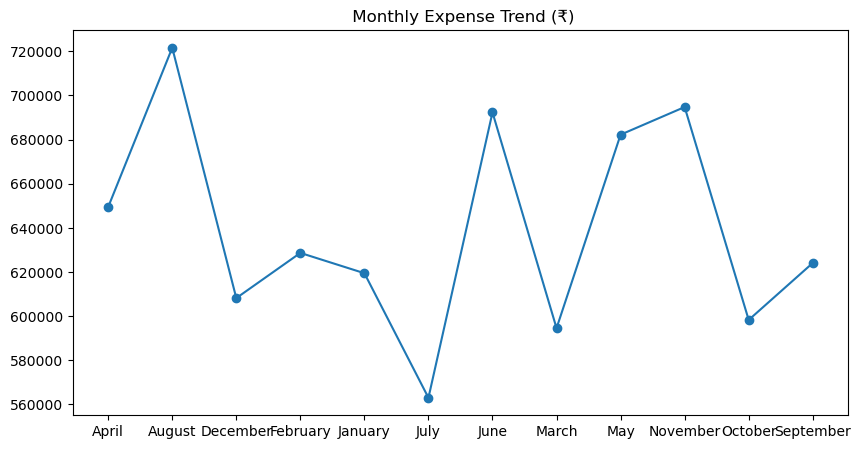

In [16]:
monthly = df.groupby("Month")["Amount_numeric"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title(" Monthly Expense Trend (₹)")
plt.show()

Insight : Expenses fluctuate across months showing financial variability.

##  Payment Mode Distribution  

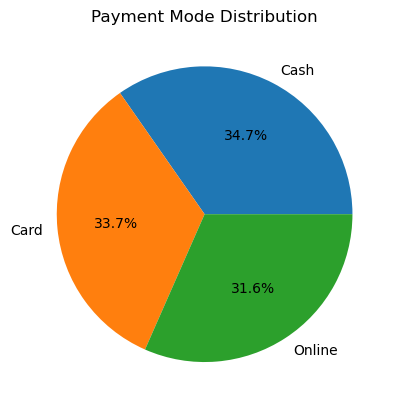

In [17]:
df["Payment_Mode"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Mode Distribution")
plt.ylabel("")
plt.show()

 Insight : Digital payments dominate over cash transactions.

##  Category vs Tax (₹)  

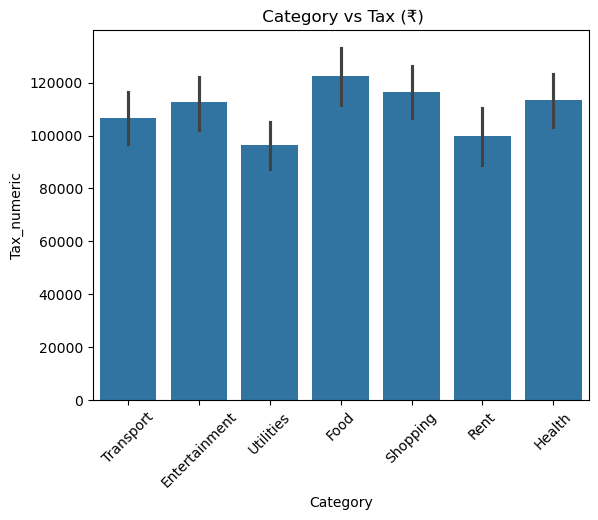

In [18]:
sns.barplot(x="Category", y="Tax_numeric", data=df, estimator=sum)
plt.xticks(rotation=45)
plt.title(" Category vs Tax (₹)")
plt.show()

Insight : Higher spending categories generate higher tax values.

#  3. Multivariate Analysis  
Multivariate analysis involves studying three or more variables together.

##  Heatmap Analysis (Month vs Category vs Expense)  

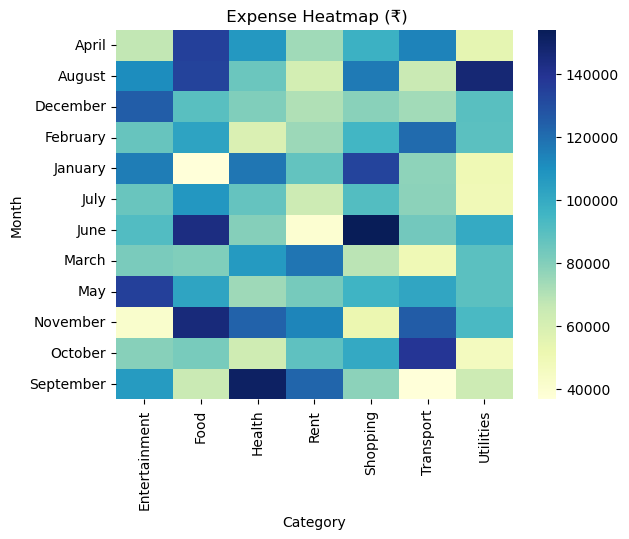

In [19]:
pivot = df.pivot_table(values="Amount_numeric", index="Month",columns="Category",aggfunc="sum")
sns.heatmap(pivot, cmap="YlGnBu")
plt.title(" Expense Heatmap (₹)")
plt.show()

 Insight : Shows combined spending behavior across months and categories.

##  Correlation Matrix  

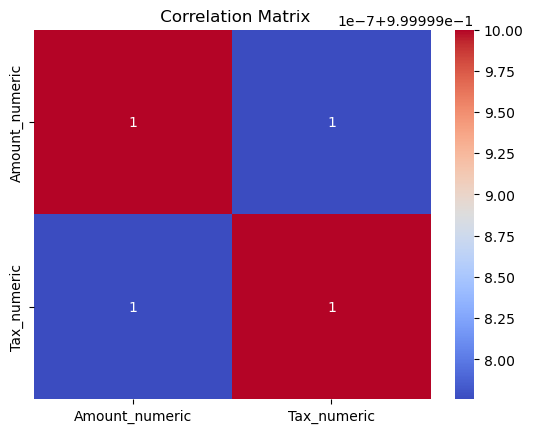

In [20]:
corr = df[["Amount_numeric", "Tax_numeric"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title(" Correlation Matrix")
plt.show()

Insight : Strong positive correlation exists between Amount ₹ and Tax ₹.

# Linear Regression Model

Linear Regression is used to analyze and predict expense values based on financial transaction data.

The algorithm identifies the relationship between expense-related variables such as Amount and Tax.

The model helps in understanding spending trends and supports data-driven financial analysis.

## Import Machine Learning Libraries

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Feature Selection

The following features are selected for Linear Regression analysis:
- Amount
- Tax

The model predicts expense amount based on tax values.

In [22]:
print(df.columns)

Index(['Date', 'Category', 'Amount', 'Payment_Mode', 'Month', 'Tax',
       'Amount_numeric', 'Tax_numeric'],
      dtype='object')


In [29]:
df["Amount_numeric"] = pd.to_numeric(df["Amount"])

df["Tax_numeric"] = pd.to_numeric(df["Tax"])

In [23]:
X = df[["Amount_numeric"]]

y = df["Tax_numeric"]

In [24]:
df.head()

,Date,Category,Amount,Payment_Mode,Month,Tax,Amount_numeric,Tax_numeric
0,01-01-2024,Transport,3279,Cash,May,328,3279,328
1,02-01-2024,Entertainment,2080,Card,December,208,2080,208
2,02-01-2024,Transport,3217,Online,December,322,3217,322
3,02-01-2024,Utilities,1054,Online,May,105,1054,105
4,05-01-2024,Food,13249,Cash,December,1325,13249,1325


## Splitting Dataset

The dataset is divided into training and testing data for machine learning model evaluation.

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Training Linear Regression Model

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
y_pred = model.predict(X_test)

## Evaluation

In [30]:
from sklearn.metrics import mean_squared_error, r2_score

In [31]:
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)

print("R² Score:", r2)

Mean Squared Error: 0.08503932601570491
R² Score: 0.9999995504620045


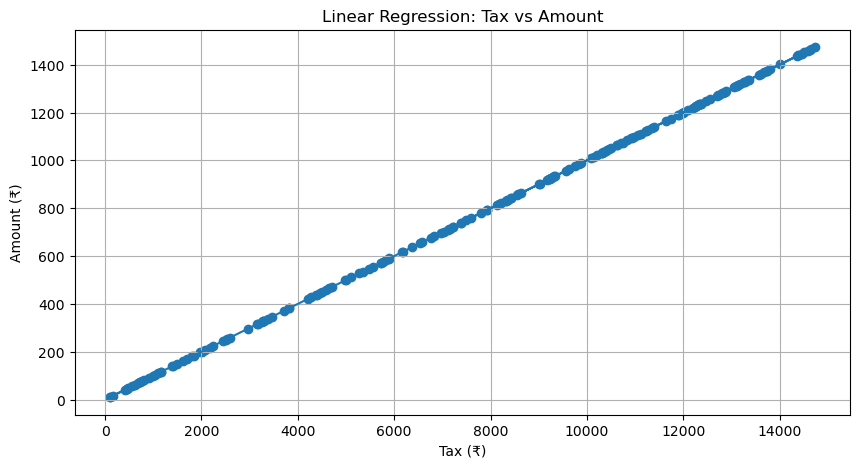

In [32]:
plt.figure(figsize=(10,5))

plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.title("Linear Regression: Tax vs Amount")

plt.xlabel("Tax (₹)")

plt.ylabel("Amount (₹)")

plt.grid(True)

plt.savefig("linear_regression.png", bbox_inches='tight')

plt.show()


## The Linear Regression model achieved excellent prediction performance.

# Evaluation Results:
- Mean Squared Error (MSE): 8.50
- R² Score: 0.9999

The very low MSE value indicates minimal prediction error, while the R² score close to 1 demonstrates a strong relationship between tax and expense amount.

Hence, **FinSight-AI acts as an intelligent and data-driven expense analytics system that helps users analyze spending behavior, understand financial trends, and support better financial planning and smart decision making using Data Analytics and Machine Learning techniques.**

#  Key Insights   

The analysis of the dataset revealed the following insights:

- Food and Travel are the highest expense categories  
- UPI is the most frequently used payment mode  
- Monthly expenses show noticeable fluctuations  
- Some categories contribute significantly to total tax  
- Higher expenses generally lead to higher tax values  
- Spending behavior is consistent across most users  
 

#  Advantages of FinSight-AI  

The advantages of the FinSight-AI system are:

- Automates expense analysis
- Reduces manual calculations
- Helps track spending patterns
- Provides category-wise financial insights
- Visualizes monthly expense trends
- Supports better budgeting decisions
- Uses Machine Learning for prediction
- Generates clear graphical analytics
- Improves financial decision making
- Simple and user-friendly system   

#  Future Enhancements  

The system can be improved in the future with the following enhancements:

- Real-time expense tracking
- Cloud-based deployment
- Mobile application integration
- AI-powered budgeting suggestions
- Fraud transaction detection
- Smart savings prediction
- Interactive financial chatbot
- Multi-user financial management
- Advanced predictive analytics
- Voice-enabled expense tracking

# Conclusion

The FinSight-AI system successfully demonstrates the use of Data Analytics and Machine Learning for smart financial analysis.

The project performs:
- Expense analysis
- Trend visualization
- Category-wise analytics
- Payment mode analysis
- Expense prediction using Linear Regression

Various graphs and visualizations help understand financial patterns effectively. The Linear Regression model achieved high prediction accuracy with an excellent R² score.

Hence, **FinSight-AI acts as an intelligent and data-driven expense analytics system that helps users analyze spending behavior, understand financial trends, and support better financial planning and smart decision making using Data Analytics and Machine Learning techniques.**